#### Data Transformation
- convert the column which has wrong datatype to correct datatype
- convert text categorical into numeric
- convert the column, which has high magnitude to low magnitude

In [17]:
import pandas as pd

In [2]:
df = pd.DataFrame({"Age":[23,25,30,"32",40,50,31]})
df

,Age
0,23
1,25
2,30
3,32
4,40
5,50
6,31


In [3]:
df.dtypes

Age    object
dtype: object

In [4]:
df["Age"].unique()

array([23, 25, 30, '32', 40, 50, 31], dtype=object)

In [6]:
df["Age"] = df["Age"].astype(int)
df.dtypes

Age    int64
dtype: object

#### Encoding
- convert discrete categorical column (text) into numreic column
- converting the text to numeric (as Machines can't understand text or ML algorithm (maths) can't be applied on text)

- each unique value -- > each category

- **Types of Encoding**
    - Nominal Encoding or Dummy Encoding or One-hot Encoding
    - Ordinal Encoding
    - label Encoding
    - Probability Encoding


In [2]:
df = pd.DataFrame({"Gender":["Male","male","female", "MALE", "female"]})
df

,Gender
0,Male
1,male
2,female
3,MALE
4,female


In [3]:
df["Gender"].unique()

array(['Male', 'male', 'female', 'MALE'], dtype=object)

In [4]:
df["Gender"] = df["Gender"].str.capitalize()
df

,Gender
0,Male
1,Male
2,Female
3,Male
4,Female


In [5]:
df["Gender"].unique()

array(['Male', 'Female'], dtype=object)

In [6]:
df["Gender"].value_counts()

Gender
Male      3
Female    2
Name: count, dtype: int64

Observe the number of categories
observe the value_counts (count of each category)

categories means the unique values in a column

**if more no.of categories:**
    label encoding
    or
    probability encoding

**when given data consists of less no. of categories,**
then observe is there any sequence b/w the categories
Sequence: can u write the categories in sequential order (ascending or descending order)|
- if sequence b/w the categories is available, then apply ordinal encoding
- if no sequence b/w the categories, then apply nominal encoding

Ex : 
Gender
- M            
- M
- M
- F
- F

categories : M, F

less or more: less

any order: no order (nominal)
Nominal Encoding 

Grade
- A+
- A
- A
- A
- B

categories : A+, A, B

less or more: less

any order : yes (B < A < A+)

Ordinal Encoding



##### Nominal Encoding or Dummy Encoding or OneHot Encoding
In this encoding technique, we create new binary columns for each category of the categorical variable. Each column represents a category, and it takes the value of 1 if the observation belongs to that category and 0 otherwise. 
This method is useful when there is no ordinal relationship between the categories.
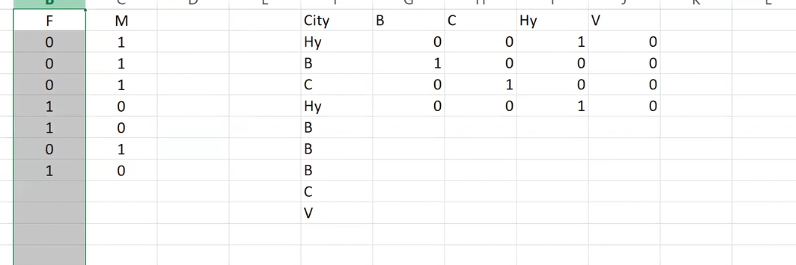

n categories should be converted to n - 1 columns because time will be less

In [8]:
df = pd.DataFrame({'city':["Hyd","Hyd","Chennai","Hyd","Bangalore","Chennai"]})
df

,city
0,Hyd
1,Hyd
2,Chennai
3,Hyd
4,Bangalore
5,Chennai


In [14]:
df1 = pd.get_dummies(df["city"] , dtype=int, drop_first=True)
# The above code will create dummy variables for the 'city' column, with 'Bangalore' as the reference category (since drop_first=True). 
# The resulting DataFrame will have two new columns: 'city_Chennai' and 'city_Hyd', 
# which will indicate the presence of those cities in the original 'city' column.
df1

,Chennai,Hyd
0,0,1
1,0,1
2,1,0
3,0,1
4,0,0
5,1,0


In [16]:
df2 = pd.get_dummies(df["city"] , dtype=int)
df2.drop(columns=["Hyd"])

,Bangalore,Chennai
0,0,0
1,0,0
2,0,1
3,0,0
4,1,0
5,0,1


##### Ordinal Encoding
In this encoding technique, we assign a unique integer to each category based on their order or rank. For example, if we have a column "Education Level" with categories "High School", "Bachelor's", "Master's", and "PhD", we can assign the following integers:
- High School: 1
- Bachelor's: 2
- Master's: 3
- PhD: 4

This method is suitable when there is a natural order or hierarchy among the categories. However, it may not be appropriate for nominal data where there is no inherent order.


In [12]:
df = pd.DataFrame({'shirt_size':["S","M","S","XL","S","L"]})
df

,shirt_size
0,S
1,M
2,S
3,XL
4,S
5,L


In [27]:
df["shirt_size"].unique()

array(['S', 'M', 'XL', 'L'], dtype=object)

In [28]:
df["shirt_size"].nunique()

4

In [29]:
df["shirt_size"].unique().shape[0]

4

In [30]:
df["shirt_size"].value_counts

<bound method IndexOpsMixin.value_counts of 0     S
1     M
2     S
3    XL
4     S
5     L
Name: shirt_size, dtype: object>

In [34]:
from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder(categories=[["S","M","L","XL"]])

df["shirt_size"] = oe.fit_transform(df[["shirt_size"]])

# The above code will encode the 'shirt_size' column using ordinal encoding, where 'S' will be encoded as 0, 'M' as 1, 'L' as 2, and 'XL' as 3. 
# The resulting DataFrame will have the 'shirt_size' column transformed into numerical values based on the specified order of sizes.
# Note that the categories parameter in OrdinalEncoder is used to specify the order of the categories for encoding.
# fit_transform (calculate and convert) is used to fit the encoder to the data and then transform it in one step.
df

,shirt_size
0,0.0
1,1.0
2,0.0
3,3.0
4,0.0
5,2.0


##### Label Encoding
- In Label encoding, each category is assigned a value from 1 to N, where N is the number of categories of that feature.
- It converts to numeric as per alphabetical order

In [3]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["shirt_size_le"] = le.fit_transform(df["shirt_size"])
df

,shirt_size,shirt_size_le
0,S,2
1,M,1
2,S,2
3,XL,3
4,S,2
5,L,0


##### Probabilty Encoding
When one of the categories have more no. of records than others
In this technique, we replace the categories with the probability of the target variable for each category.

In [13]:
df["shirt_size"].value_counts() / len(df)

shirt_size
S     0.500000
M     0.166667
XL    0.166667
L     0.166667
Name: count, dtype: float64

In [14]:
# In probabilty encoding we replace the categories with the probability of the target variable for each category.
# For example, if we have a target variable 'purchase' and a categorical variable 'shirt_size', we can calculate the probability of purchase for each shirt size and replace the shirt size categories with those probabilities.
# This can be useful in cases where there is a strong relationship between the categorical variable and the target variable, as it can help the model to capture that relationship more effectively.
df["shirt_size_pe"] = df["shirt_size"].map({"S" : 0.5, "M" : 0.166, "L" : 0.166, "XL" : 0.166})
# The above code will replace the values in the 'shirt_size' column with the specified probabilities.   
# The map function is used to map the original categories to their corresponding probabilities.
df

,shirt_size,shirt_size_pe
0,S,0.500
1,M,0.166
2,S,0.500
3,XL,0.166
4,S,0.500
5,L,0.166


**When we have exactly 2 categories in the categorical columns**
- You can apply , either label encoding or dummy encoding (both will gave same o/p).

**Whenver you recieve any raw data with encoded, then by default it applied with label encoding**

#### Scaling
Scaling is a technique used to bring all the features to the same level of magnitude. 
This is important because many machine learning algorithms are sensitive to the scale of the features. 
If one feature has a much larger range than another, it can dominate the learning process and lead to suboptimal performance.

In continuous variables apply scaling whereas in categorical variables apply encoding.

- when u have some columns with big numbers(high magnitude) & some columns with small numbers(low magnitude)
- bring all columns to same level magnitude, beacuse machine should think big number column is more important

1. Min-Max Scaling (if algorithm was designed, by assuming data between 0 to 1)
2. Standard Scaling (if algorithm was designed, by assuming data between -inf to inf)

In [15]:
import pandas as pd

df = pd.DataFrame({"X" : [1,2,3,4,5]})
df

,X
0,1
1,2
2,3
3,4
4,5


In [18]:
# All the values are scaled between 0 to 1.
# Formula for min-max scaling: (X - X_min) / (X_max - X_min)
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df["X_mm"] = scaler.fit_transform(df[["X"]])
df

,X,X_mm
0,1,0.00
1,2,0.25
2,3,0.50
3,4,0.75
4,5,1.00


In [20]:
# Standard Scaling (Z-score normalization) is a technique used to standardize the features of a dataset by 
# transforming them to have a mean of 0 and a standard deviation of 1.
# The formula for standard scaling is: (X - mean) / std deviation
# This transformation is useful when the features have different scales and we want to bring them to a common scale 
# without distorting the differences in the ranges of values.

# std deviation = sqrt(mean((X - mean)^2))
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df["X_ss"] = scaler.fit_transform(df[["X"]])
df

,X,X_mm,X_ss
0,1,0.00,-1.414214
1,2,0.25,-0.707107
2,3,0.50,0.000000
3,4,0.75,0.707107
4,5,1.00,1.414214
